# Ejercicio 6 - Parquet versus tablas DuckDB

Este notebook **no ejecuta el benchmark**: lee los resultados que deja
`scripts/benchmark.py` en `docs/06_benchmark/` y los organiza en tablas y
graficos. Para volver a medir:

```bash
docker exec lab8-lab python scripts/benchmark.py
```

Cada consulta se ejecuta con el mismo texto SQL en dos estrategias: vistas
sobre los Parquet (`sql/04_analisis/00_vistas.sql`) y una tabla materializada
con `scripts/materializar.py`. El script verifica que ambas devuelvan el mismo
resultado. La documentacion y el analisis estan en `docs/06_benchmark.md`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_RESULTADOS = RAIZ / "docs" / "06_benchmark"
DIR_FIGURAS = RAIZ / "docs" / "figuras"
pd.set_option("display.width", 200)

# --- Estilo de los graficos (mismo que notebooks/04) -------------------------
# Paleta de referencia (skill dataviz), colores fijos por entidad.
COLOR_ESTRATEGIA = {"parquet": "#2a78d6", "tabla": "#eb6834"}   # azul, naranja
GRIS = "#898781"
TINTA, TINTA_2, REJILLA, EJE = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.family": "sans-serif", "font.size": 10,
    "text.color": TINTA, "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": GRIS, "ytick.color": GRIS, "axes.edgecolor": EJE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "lines.linewidth": 2, "lines.markersize": 8, "legend.frameon": False, "figure.dpi": 110,
})


def guardar(fig, nombre: str):
    fig.savefig(DIR_FIGURAS / f"{nombre}.png", dpi=130, bbox_inches="tight")

tiempos = pd.read_csv(DIR_RESULTADOS / "tiempos.csv")
escalas = pd.read_csv(DIR_RESULTADOS / "escalas.csv")
print((DIR_RESULTADOS / "ambiente.txt").read_text())
ORDEN_ESCALAS = list(escalas.escala)
NOMBRES = dict(zip(tiempos.consulta, tiempos.nombre))

fecha: 2026-10-08 05:29
duckdb: 1.5.5
python: 3.11.14
hilos: 24
memory_limit: 3GB
repeticiones: 3 (+1 primera ejecucion)



## Escalas de datos y costo de materializar

In [2]:
tabla_escalas = escalas.assign(
    filas_millones=(escalas.filas / 1e6).round(2),
    tabla_vs_parquet=(escalas.tabla_mib / escalas.parquet_mib).round(2),
)[["descripcion", "archivos", "filas_millones", "parquet_mib", "tabla_mib", "tabla_vs_parquet", "carga_segundos"]]
tabla_escalas

,descripcion,archivos,filas_millones,parquet_mib,tabla_mib,tabla_vs_parquet,carga_segundos
0,1 mes (2026-01),2,3.77,62.1,118.0,1.90,1.98
1,3 meses (2026-01 a 03),6,11.20,184.8,357.0,1.93,4.96
2,2026 (8 meses),16,30.04,495.7,938.0,1.89,11.00
3,2024 + 2026 (20 meses),40,71.87,1171.7,2225.3,1.90,24.94


## Tiempos por consulta

`primera` = primera ejecucion en una conexion recien abierta; `repetida` =
mediana de las ejecuciones siguientes. `x` = cuantas veces mas lenta es la
consulta sobre Parquet que sobre la tabla.

In [3]:
def resumen(ejecucion: str) -> pd.DataFrame:
    d = (tiempos[tiempos.ejecucion == ejecucion]
         .groupby(["escala", "consulta", "estrategia"]).segundos.median()
         .unstack("estrategia"))
    d["x"] = (d.parquet / d.tabla).round(1)
    return d

repetida = resumen("repetida")
primera = resumen("primera")
tabla = pd.concat({"primera": primera, "repetida": repetida}, axis=1)
tabla = tabla.reindex(ORDEN_ESCALAS, level="escala")
tabla.round(3)

primera              repetida              
estrategia      parquet  tabla     x  parquet  tabla      x
escala consulta                                            
1mes   B1         0.150  0.041   3.7    0.067  0.012    5.4
       B2         0.148  0.036   4.1    0.201  0.004   45.8
       B3         0.379  0.344   1.1    0.425  0.079    5.4
       B4         0.323  0.064   5.1    0.287  0.064    4.5
       B5         0.370  0.068   5.5    0.472  0.066    7.2
       B6         0.522  0.068   7.6    0.524  0.062    8.5
       B7         0.527  0.183   2.9    0.734  0.180    4.1
       B8         0.481  0.110   4.3    0.442  0.120    3.7
       B9         0.543  0.151   3.6    0.683  0.154    4.4
3meses B1         0.141  0.093   1.5    0.181  0.031    5.8
       B2         0.260  0.038   6.8    0.232  0.005   49.4
       B3         0.937  0.917   1.0    0.934  0.208    4.5
       B4         0.641  0.166   3.9    0.660  0.183    3.6
       B5         0.775  0.201   3.9    0.695  0.177    3.9
       B6         1.193  0.179   6.7    1.171  0.162    7.2
       B7         1.184  0.575   2.1    1.115  0.529    2.1
       B8         0.940  0.405   2.3    0.978  0.423    2.3
       B9         0.928  0.318   2.9    0.958  0.330    2.9
2026   B1         0.419  0.240   1.7    0.351  0.072    4.9
       B2         0.701  0.064  11.0    0.664  0.005  141.3
       B3         3.928  2.523   1.6    3.558  0.541    6.6
       B4         1.977  0.426   4.6    2.169  0.415    5.2
       B5         2.530  0.572   4.4    2.025  0.420    4.8
       B6         4.234  0.399  10.6    3.806  0.429    8.9
       B7         3.013  1.455   2.1    3.156  1.288    2.5
       B8         2.574  1.176   2.2    2.518  1.231    2.0
       B9         2.406  0.875   2.7    2.315  0.917    2.5
todo   B1         0.970  0.602   1.6    0.798  0.141    5.7
       B2         1.496  0.074  20.1    1.491  0.007  222.5
       B3         6.183  6.721   0.9    5.478  1.374    4.0
       B4         3.541  0.922   3.8    3.669  0.991    3.7
       B5         4.394  2.556   1.7    4.371  3.569    1.2
       B6         8.137  3.631   2.2    8.339  0.967    8.6
       B7         6.773  3.557   1.9    7.253  3.312    2.2
       B8         5.272  3.364   1.6    5.284  3.084    1.7
       B9         4.482  2.008   2.2    4.750  1.935    2.5

In [4]:
# Tabla principal para docs/06_benchmark.md: escala completa (2024 + 2026)
escala_mayor = ORDEN_ESCALAS[-1]
principal = tabla.loc[escala_mayor].copy()
principal.insert(0, "nombre", [NOMBRES[c] for c in principal.index])
principal.round(2)

nombre primera             repetida             
estrategia                           parquet tabla     x  parquet tabla      x
consulta                                                                      
B1                    Conteo por mes    0.97  0.60   1.6     0.80  0.14    5.7
B2                Consulta selectiva    1.50  0.07  20.1     1.49  0.01  222.5
B3                Todas las columnas    6.18  6.72   0.9     5.48  1.37    4.0
B4                  Dia de la semana    3.54  0.92   3.8     3.67  0.99    3.7
B5          Mapa de calor dia x hora    4.39  2.56   1.7     4.37  3.57    1.2
B6                 Zonas principales    8.14  3.63   2.2     8.34  0.97    8.6
B7                Propina por metodo    6.77  3.56   1.9     7.25  3.31    2.2
B8                  Tarifa por milla    5.27  3.36   1.6     5.28  3.08    1.7
B9            Atipicos por proveedor    4.48  2.01   2.2     4.75  1.93    2.5

In [5]:
# Totales de las 9 consultas por escala (suma de medianas)
totales = (repetida.groupby("escala")[["parquet", "tabla"]].sum()
           .reindex(ORDEN_ESCALAS))
totales["x"] = (totales.parquet / totales.tabla).round(1)
totales = totales.join(escalas.set_index("escala")[["filas", "carga_segundos"]])
# Cuantas ejecuciones del conjunto completo de consultas amortizan la carga
totales["ejecuciones_para_amortizar_carga"] = (
    totales.carga_segundos / (totales.parquet - totales.tabla)).round(1)
totales.round(2)

,parquet,tabla,x,filas,carga_segundos,ejecuciones_para_amortizar_carga
escala,,,,,,
1mes,3.84,0.74,5.2,3765161,1.98,0.6
3meses,6.92,2.05,3.4,11199059,4.96,1.0
2026,20.56,5.32,3.9,30040469,11.00,0.7
todo,41.43,15.38,2.7,71870407,24.94,1.0


## Como cambia el tiempo con la cantidad de datos

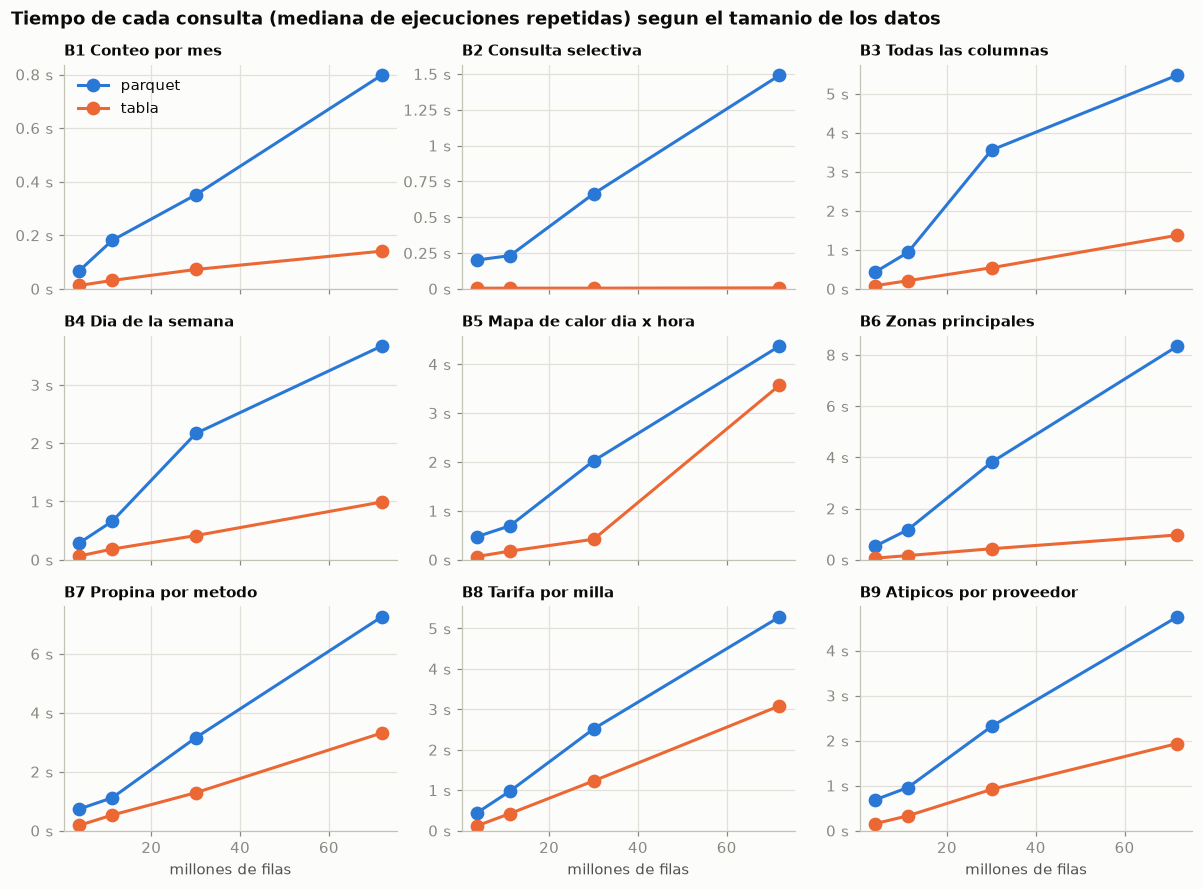

In [6]:
consultas = list(dict.fromkeys(tiempos.consulta))
fig, ejes = plt.subplots(3, 3, figsize=(11, 8.2), sharex=True)
filas_m = escalas.set_index("escala").filas / 1e6
for ax, consulta in zip(ejes.flat, consultas):
    for estrategia, color in COLOR_ESTRATEGIA.items():
        s = repetida.xs(consulta, level="consulta")[estrategia].reindex(ORDEN_ESCALAS)
        ax.plot(filas_m.reindex(ORDEN_ESCALAS), s, marker="o", color=color, label=estrategia)
    ax.set_title(f"{consulta} {NOMBRES[consulta]}", fontsize=10)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g} s"))
for ax in ejes[-1]:
    ax.set_xlabel("millones de filas")
ejes[0, 0].legend(loc="upper left")
fig.suptitle("Tiempo de cada consulta (mediana de ejecuciones repetidas) segun el tamanio de los datos",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
guardar(fig, "ej6_tiempo_vs_filas")

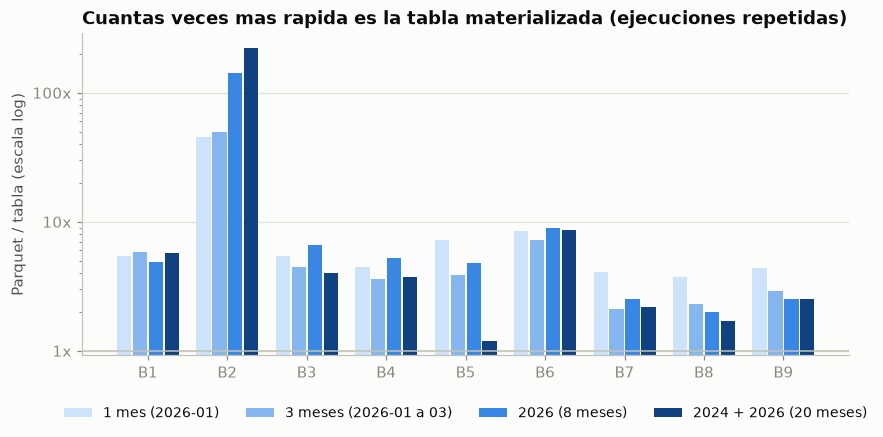

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.8))
d = repetida["x"].unstack("escala")[ORDEN_ESCALAS]
ancho = 0.2
for i, escala in enumerate(ORDEN_ESCALAS):
    descripcion = escalas.set_index("escala").descripcion[escala]
    tono = ["#cde2fb", "#86b6ef", "#3987e5", "#104281"][i]   # rampa azul secuencial: mas datos = mas oscuro
    ax.bar([j + (i - 1.5) * ancho for j in range(len(d))], d[escala], width=ancho - 0.02,
           color=tono, label=descripcion)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}x"))
ax.set_xticks(range(len(d)), d.index)
ax.axhline(1, color=EJE, linewidth=1)
ax.set_ylabel("Parquet / tabla (escala log)")
ax.set_title("Cuantas veces mas rapida es la tabla materializada (ejecuciones repetidas)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=4, fontsize=9)
ax.grid(axis="x", visible=False)
guardar(fig, "ej6_aceleracion")

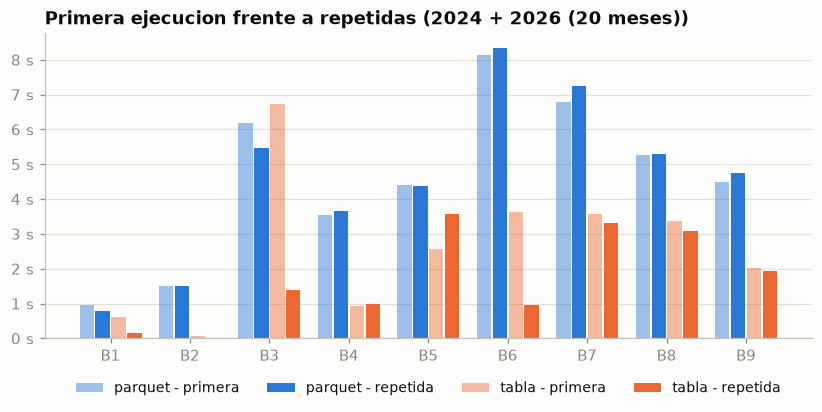

In [8]:
# Primera ejecucion vs repetida en la escala completa: efecto de la cache
d = tabla.loc[escala_mayor]
fig, ax = plt.subplots(figsize=(9, 3.6))
x = range(len(d))
for k, (estrategia, ejecucion) in enumerate([("parquet", "primera"), ("parquet", "repetida"),
                                            ("tabla", "primera"), ("tabla", "repetida")]):
    color = COLOR_ESTRATEGIA[estrategia]
    ax.bar([i + (k - 1.5) * 0.2 for i in x], d[(ejecucion, estrategia)], width=0.18,
           color=color, alpha=1.0 if ejecucion == "repetida" else 0.45,
           label=f"{estrategia} - {ejecucion}")
ax.set_xticks(list(x), d.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g} s"))
ax.set_title(f"Primera ejecucion frente a repetidas ({escalas.set_index('escala').descripcion[escala_mayor]})")
ax.legend(ncols=4, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.1))
ax.grid(axis="x", visible=False)
guardar(fig, "ej6_primera_vs_repetida")